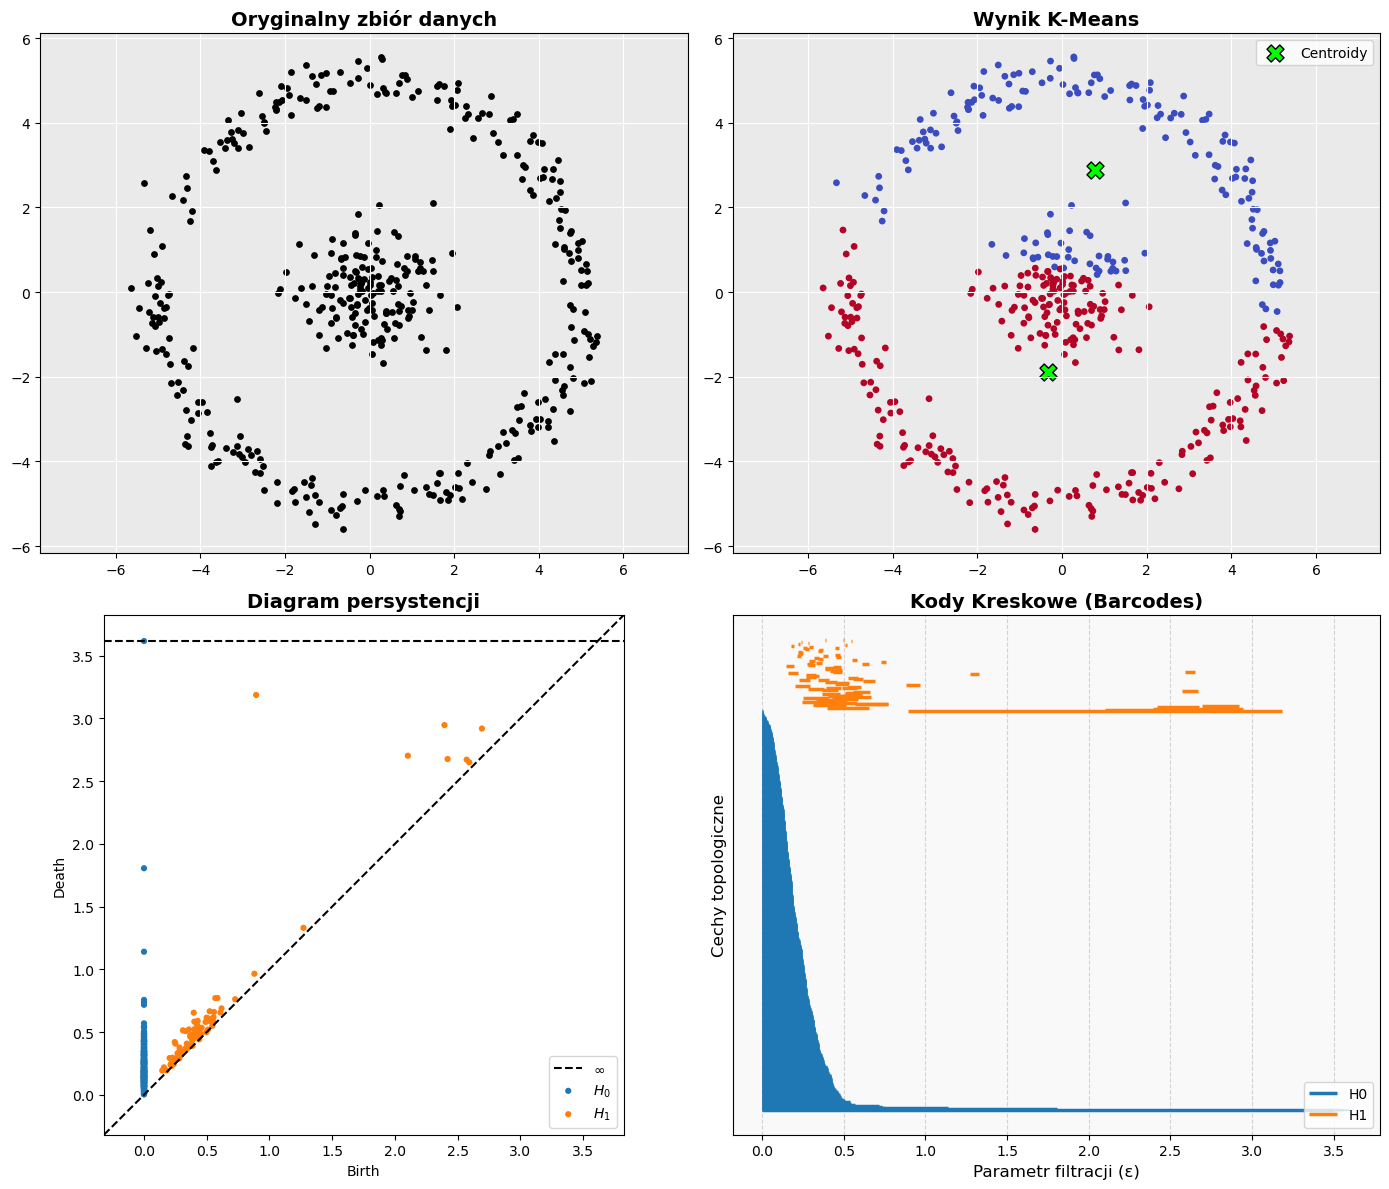

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from ripser import ripser
from persim import plot_diagrams

# ==========================================
# 1. Generowanie danych (Bullseye: Pierścień i środek)
# ==========================================
np.random.seed(42)

# Parametry dla zewnętrznego pierścienia
n_ring = 300
r_ring = 5.0
theta = np.random.uniform(0, 2*np.pi, n_ring)
noise_ring = np.random.normal(0, 0.3, n_ring)
x_ring = (r_ring + noise_ring) * np.cos(theta)
y_ring = (r_ring + noise_ring) * np.sin(theta)

# Parametry dla wewnętrznego klastra (bloba)
n_blob = 150
x_blob = np.random.normal(0, 0.8, n_blob)
y_blob = np.random.normal(0, 0.8, n_blob)

# Łączenie w jeden zbiór danych X
X_ring = np.column_stack((x_ring, y_ring))
X_blob = np.column_stack((x_blob, y_blob))
X = np.vstack((X_ring, X_blob))

# ==========================================
# 2. Algorytm K-Means
# ==========================================
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# ==========================================
# 3. Topologiczna Analiza Danych (Ripser)
# ==========================================
# maxdim=1 liczy spójne składowe (H0) oraz pętle (H1)
rips = ripser(X, maxdim=1)
diagrams = rips['dgms']

# ==========================================
# 4. Wizualizacja wyników (Siatka 2x2)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.patch.set_facecolor('white')

# --- Wykres 1: Surowe dane ---
axes[0, 0].scatter(X[:, 0], X[:, 1], c='black', s=15)
axes[0, 0].set_title("Oryginalny zbiór danych", fontsize=14, fontweight='bold')
axes[0, 0].axis('equal')
axes[0, 0].set_facecolor('#EAEAEA')
axes[0, 0].grid(color='white')

# --- Wykres 2: Wynik K-Means ---
axes[0, 1].scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm', s=15)
axes[0, 1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                   c='lime', marker='X', s=150, edgecolor='black', label='Centroidy')
axes[0, 1].set_title("Wynik K-Means", fontsize=14, fontweight='bold')
axes[0, 1].axis('equal')
axes[0, 1].set_facecolor('#EAEAEA')
axes[0, 1].grid(color='white')
axes[0, 1].legend()

# --- Wykres 3: Diagram persystencji (Ripser/Persim) ---
plt.sca(axes[1, 0]) 
plot_diagrams(diagrams, show=False, ax=axes[1, 0])
axes[1, 0].set_title("Diagram persystencji", fontsize=14, fontweight='bold')

# --- Wykres 4: Ręczne rysowanie Barcode'ów ---
ax_bar = axes[1, 1]
y_curr = 0 # Oś Y to po prostu kolejne linie
colors = ['#1f77b4', '#ff7f0e'] # Niebieski dla H0, Pomarańczowy dla H1
labels_added = [False, False]

# Maksymalna wartość do narysowania linii w nieskończoność (np. dla głównej składowej)
max_death = max([max([d for b, d in dgm if d != np.inf] + [0]) for dgm in diagrams]) * 1.1

for dim, dgm in enumerate(diagrams):
    dgm_sorted = sorted(dgm, key=lambda x: (x[1]-x[0]) if x[1] != np.inf else float('inf'), reverse=True)
    
    for birth, death in dgm_sorted:
        is_inf = False
        if death == np.inf:
            death = max_death
            is_inf = True
            
        label = f"H{dim}" if not labels_added[dim] else ""
        
        ax_bar.hlines(y=y_curr, xmin=birth, xmax=death, color=colors[dim], lw=2.5, label=label)
        
        if is_inf:
            ax_bar.arrow(death - 0.2, y_curr, 0.2, 0, head_width=2, head_length=0.1, fc=colors[dim], ec=colors[dim])
            
        y_curr += 1
        labels_added[dim] = True

ax_bar.set_title("Kody Kreskowe (Barcodes)", fontsize=14, fontweight='bold')
ax_bar.set_xlabel("Parametr filtracji (ε)", fontsize=12)
ax_bar.set_ylabel("Cechy topologiczne", fontsize=12)
ax_bar.set_yticks([]) 
ax_bar.legend(loc='lower right')
ax_bar.set_facecolor('#f9f9f9')
ax_bar.grid(axis='x', color='lightgray', linestyle='--')

plt.tight_layout()

# ==========================================
# 5. Zapis do pliku PDF i wyświetlenie
# ==========================================
# Zapisujemy do pliku PDF (bbox_inches='tight' usuwa niepotrzebne białe marginesy dookoła)
plt.savefig("bullseye_tda_vs_kmeans.pdf", format='pdf', bbox_inches='tight')

# Wyświetlamy okienko z wykresem (opcjonalnie)
plt.show()

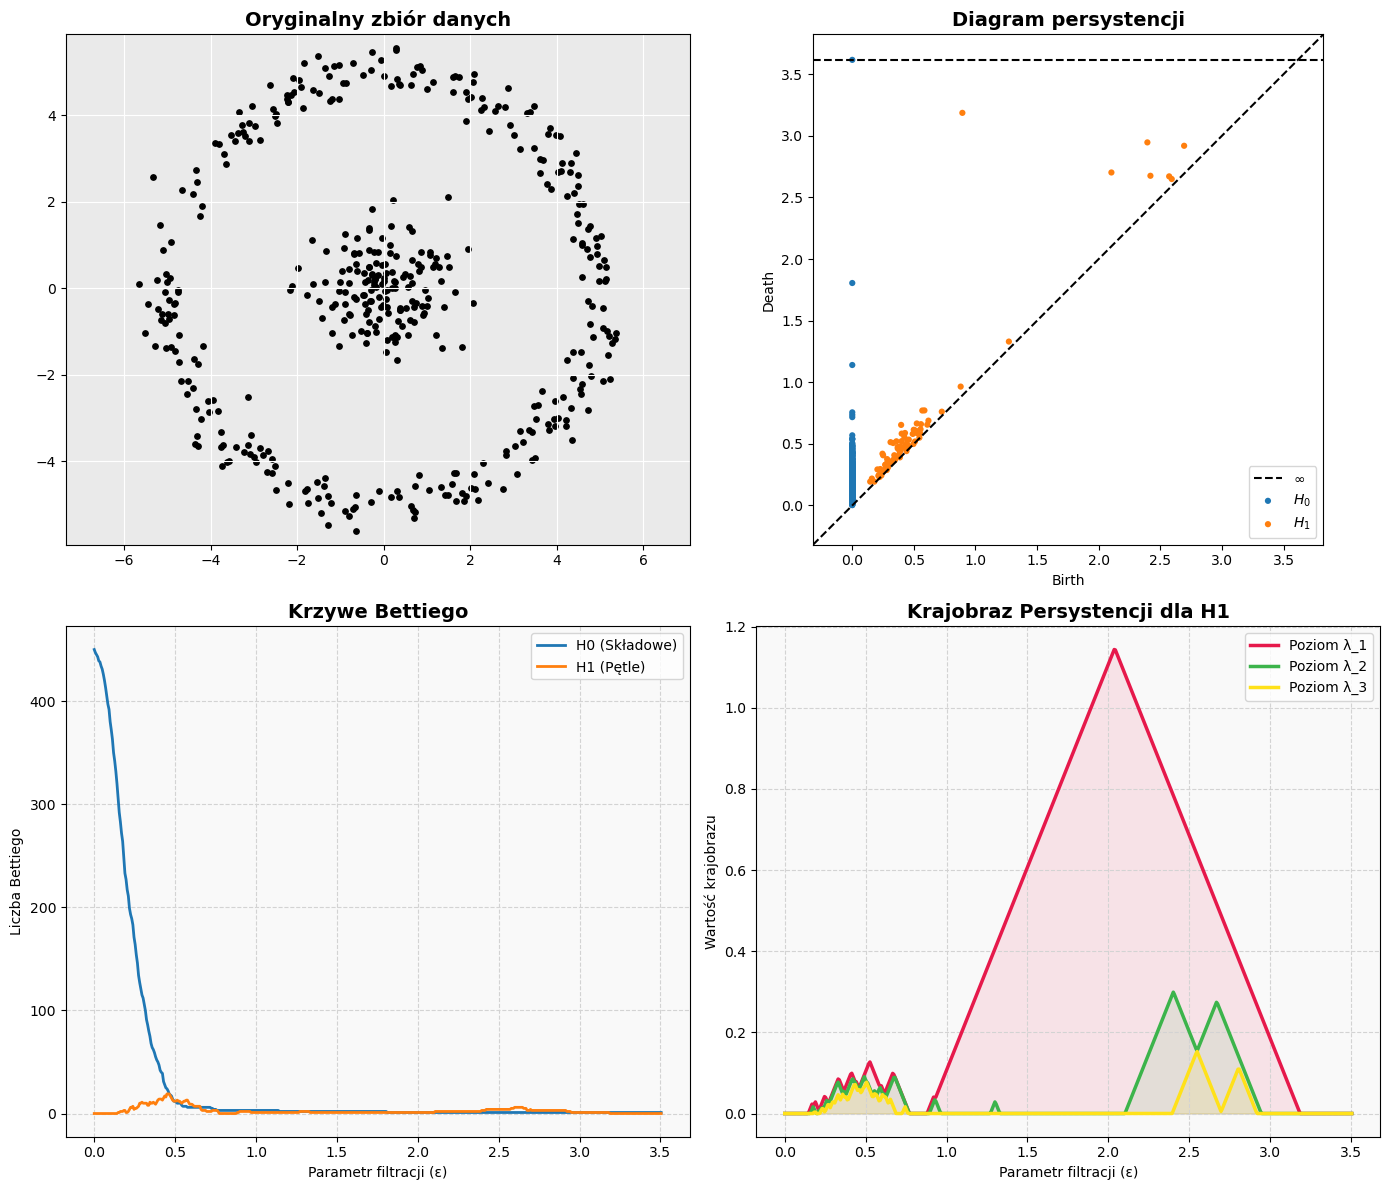

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams

# ==========================================
# 1. Generowanie danych (Bullseye)
# ==========================================
np.random.seed(42)
n_ring, r_ring = 300, 5.0
theta = np.random.uniform(0, 2*np.pi, n_ring)
noise_ring = np.random.normal(0, 0.3, n_ring)
x_ring = (r_ring + noise_ring) * np.cos(theta)
y_ring = (r_ring + noise_ring) * np.sin(theta)

n_blob = 150
x_blob = np.random.normal(0, 0.8, n_blob)
y_blob = np.random.normal(0, 0.8, n_blob)

X = np.vstack((np.column_stack((x_ring, y_ring)), np.column_stack((x_blob, y_blob))))

# ==========================================
# 2. Ripser (Diagramy)
# ==========================================
rips = ripser(X, maxdim=1)
diagrams = rips['dgms']

# ==========================================
# 3. Krzywe Bettiego
# ==========================================
max_eps = max([max([d for b, d in dgm if d != np.inf] + [0]) for dgm in diagrams]) * 1.1
eps_values = np.linspace(0, max_eps, 500)

betti_0 = [sum(1 for b, d in diagrams[0] if b <= eps and d > eps) for eps in eps_values]
betti_1 = [sum(1 for b, d in diagrams[1] if b <= eps and d > eps) for eps in eps_values]

# ==========================================
# 4. Krajobraz Persystencji (Persistent Landscape)
# ==========================================
def compute_landscape(dgm, t_vals, k_max=3):
    """Ręczna implementacja krajobrazu persystencji dla diagramu (filtruje nieskończoności)"""
    tents = []
    for b, d in dgm:
        if d == np.inf: 
            continue # Pomijamy cechy nieskończone, aby krajobraz był skończony
        # Funkcja "namiotu": max(0, min(t-b, d-t))
        tent = np.maximum(0, np.minimum(t_vals - b, d - t_vals))
        tents.append(tent)
        
    if not tents:
        return np.zeros((k_max, len(t_vals)))
        
    # Sortujemy namioty malejąco w każdym punkcie t
    tents_sorted = np.sort(np.array(tents), axis=0)[::-1, :]
    
    # Uzupełniamy zerami, jeśli jest mniej cech niż k_max
    if tents_sorted.shape[0] < k_max:
        pad = np.zeros((k_max - tents_sorted.shape[0], len(t_vals)))
        tents_sorted = np.vstack([tents_sorted, pad])
        
    return tents_sorted[:k_max, :]

# Wyliczamy 3 pierwsze poziomy krajobrazu dla grupy H1 (Pętle)
landscapes_H1 = compute_landscape(diagrams[1], eps_values, k_max=3)

# ==========================================
# 5. Wizualizacja (2x2 Dashboard TDA)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.patch.set_facecolor('white')

# --- Wykres 1: Surowe dane ---
axes[0, 0].scatter(X[:, 0], X[:, 1], c='black', s=15)
axes[0, 0].set_title("Oryginalny zbiór danych", fontsize=14, fontweight='bold')
axes[0, 0].axis('equal')
axes[0, 0].grid(color='white')
axes[0, 0].set_facecolor('#EAEAEA')

# --- Wykres 2: Diagram persystencji ---
plt.sca(axes[0, 1]) 
plot_diagrams(diagrams, show=False, ax=axes[0, 1])
axes[0, 1].set_title("Diagram persystencji", fontsize=14, fontweight='bold')

# --- Wykres 3: Krzywe Bettiego ---
axes[1, 0].plot(eps_values, betti_0, label='H0 (Składowe)', color='#1f77b4', lw=2)
axes[1, 0].plot(eps_values, betti_1, label='H1 (Pętle)', color='#ff7f0e', lw=2)
axes[1, 0].set_title("Krzywe Bettiego", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Parametr filtracji (ε)")
axes[1, 0].set_ylabel("Liczba Bettiego")
axes[1, 0].grid(color='lightgray', linestyle='--')
axes[1, 0].legend()
axes[1, 0].set_facecolor('#f9f9f9')

# --- Wykres 4: Krajobraz persystencji dla H1 ---
colors_ls = ['#e6194b', '#3cb44b', '#ffe119']
for k in range(3):
    axes[1, 1].plot(eps_values, landscapes_H1[k], label=f'Poziom λ_{k+1}', color=colors_ls[k], lw=2.5)
    axes[1, 1].fill_between(eps_values, landscapes_H1[k], alpha=0.1, color=colors_ls[k])

axes[1, 1].set_title("Krajobraz Persystencji dla H1", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Parametr filtracji (ε)")
axes[1, 1].set_ylabel("Wartość krajobrazu")
axes[1, 1].grid(color='lightgray', linestyle='--')
axes[1, 1].legend()
axes[1, 1].set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig("bullseye_tda_landscape.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams

# ==========================================
# 1. Generowanie danych (Bullseye)
# ==========================================
np.random.seed(42)
n_ring, r_ring = 300, 5.0
theta = np.random.uniform(0, 2*np.pi, n_ring)
noise_ring = np.random.normal(0, 0.3, n_ring)
x_ring = (r_ring + noise_ring) * np.cos(theta)
y_ring = (r_ring + noise_ring) * np.sin(theta)

n_blob = 150
x_blob = np.random.normal(0, 0.8, n_blob)
y_blob = np.random.normal(0, 0.8, n_blob)

X = np.vstack((np.column_stack((x_ring, y_ring)), np.column_stack((x_blob, y_blob))))

# ==========================================
# 2. Ripser (Diagramy)
# ==========================================
rips = ripser(X, maxdim=1)
diagrams = rips['dgms']

# ==========================================
# 3. Krzywe Bettiego & Krajobraz Persystencji
# ==========================================
max_eps = max([max([d for b, d in dgm if d != np.inf] + [0]) for dgm in diagrams]) * 1.1
eps_values = np.linspace(0, max_eps, 500)

betti_0 = [sum(1 for b, d in diagrams[0] if b <= eps and d > eps) for eps in eps_values]
betti_1 = [sum(1 for b, d in diagrams[1] if b <= eps and d > eps) for eps in eps_values]

def compute_landscape(dgm, t_vals, k_max=3):
    tents = []
    for b, d in dgm:
        if d == np.inf: 
            continue
        tent = np.maximum(0, np.minimum(t_vals - b, d - t_vals))
        tents.append(tent)
        
    if not tents:
        return np.zeros((k_max, len(t_vals)))
        
    tents_sorted = np.sort(np.array(tents), axis=0)[::-1, :]
    
    if tents_sorted.shape[0] < k_max:
        pad = np.zeros((k_max - tents_sorted.shape[0], len(t_vals)))
        tents_sorted = np.vstack([tents_sorted, pad])
        
    return tents_sorted[:k_max, :]

landscapes_H1 = compute_landscape(diagrams[1], eps_values, k_max=3)

# ==========================================
# 4. Eksport do osobnych plików PNG
# ==========================================

# --- Rysunek 1: Surowe dane ---
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c='black', s=15)
plt.title("Data", fontsize=14, fontweight='bold')
plt.axis('equal')
plt.grid(color='lightgray', linestyle='--')
plt.tight_layout()
plt.savefig("plot_1_raw_data.png", format='png', dpi=300, bbox_inches='tight')
plt.close()

# --- Rysunek 2: Diagram persystencji ---
plt.figure(figsize=(6, 6))
plot_diagrams(diagrams, show=False)
plt.title("Persistence Diagram", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_2_persistence_diagram.png", format='png', dpi=300, bbox_inches='tight')
plt.close()

# --- Rysunek 3: Krzywe Bettiego ---
plt.figure(figsize=(8, 5))
plt.plot(eps_values, betti_0, label='$H_0$ (Connected Components)', color='#1f77b4', lw=2)
plt.plot(eps_values, betti_1, label='$H_1$ (Loops)', color='#ff7f0e', lw=2)
plt.title("Betti Curves", fontsize=14, fontweight='bold')
plt.xlabel("Filtration Parameter (ε)")
plt.ylabel("Betti Number")
plt.grid(color='lightgray', linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig("plot_3_betti_curves.png", format='png', dpi=300, bbox_inches='tight')
plt.close()

# --- Rysunek 4: Krajobraz persystencji dla H1 ---
plt.figure(figsize=(8, 5))
colors_ls = ['#e6194b', '#3cb44b', '#ffe119']
for k in range(3):
    plt.plot(eps_values, landscapes_H1[k], label=f'Level $λ_{k+1}$', color=colors_ls[k], lw=2.5)
    plt.fill_between(eps_values, landscapes_H1[k], alpha=0.1, color=colors_ls[k])

plt.title("Persistence Landscape H1", fontsize=14, fontweight='bold')
plt.xlabel("Filtration Parameter (ε)")
plt.ylabel("Landscape Value")
plt.grid(color='lightgray', linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig("plot_4_persistent_landscape.png", format='png', dpi=300, bbox_inches='tight')
plt.close()

# --- Rysunek 5: Kody Kreskowe (Barcodes) ---
plt.figure(figsize=(8, 5))
y_curr = 0
colors = ['#1f77b4', '#ff7f0e']
labels_added = [False, False]

for dim, dgm in enumerate(diagrams):
    dgm_sorted = sorted(dgm, key=lambda x: (x[1]-x[0]) if x[1] != np.inf else float('inf'), reverse=True)
    
    for birth, death in dgm_sorted:
        is_inf = False
        if death == np.inf:
            death = max_eps
            is_inf = True
            
        label = f"$H_{dim}$" if not labels_added[dim] else ""
        plt.hlines(y=y_curr, xmin=birth, xmax=death, color=colors[dim], lw=2.5, label=label)
        
        # Rysowanie strzałki dla cech nieskończonych
        if is_inf:
            plt.arrow(death - 0.2, y_curr, 0.2, 0, head_width=2, head_length=0.1, fc=colors[dim], ec=colors[dim])
            
        y_curr += 1
        labels_added[dim] = True

plt.title("Barcodes", fontsize=14, fontweight='bold')
plt.xlabel("Filtration Parameter (ε)")
plt.ylabel("Topological Features")
plt.yticks([]) 
plt.grid(axis='x', color='lightgray', linestyle='--')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("plot_5_barcodes.png", format='png', dpi=300, bbox_inches='tight')
plt.close()

print("Wygenerowano 5 pliki PNG pomyślnie.")

Wygenerowano 5 pliki PNG pomyślnie.
